# Our classifier study

## Importations

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.effects

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical

from classification.datasets import Dataset
from classification.utils.audio_student import AudioUtil, Feature_vector_DS
from classification.utils.utils import accuracy
from classification.utils.plots import (
    plot_decision_boundaries,
    plot_specgram,
    show_confusion_matrix,
)

import pickle

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
np.random.seed(42)
tf.random.set_seed(42)

import wandb
from wandb.integration.keras import WandbMetricsLogger, WandbModelCheckpoint

TensorFlow version: 2.15.1
GPU Available: []


## Config

In [2]:
class Config:
    """Centralized configuration"""

    # ── Audio parameters ──────────────────────────────────────
    SAMPLE_RATE   = 11025
    DURATION_MS   = 950
    N_FFT         = 512
    N_MEL         = 20
    STEP_SIZE     = 51

    # ── Data augmentation flags ───────────────────────────────
    AUG_TIME_SHIFT   = True
    AUG_PITCH_SHIFT  = True
    AUG_TIME_STRETCH = True
    AUG_NOISE        = True
    AUG_SPEC_MASKING = True

    # ── Augmentation parameters ───────────────────────────────
    PITCH_SHIFT_RANGE  = (-2, 2)      # semitones
    TIME_STRETCH_RANGE = (0.9, 1.1)
    NOISE_SIGMA        = 0.05

    # ── Model architecture ────────────────────────────────────
    DENSE_UNITS  = [256, 128, 64]
    DROPOUT_RATE = 0.4
    ACTIVATION   = 'relu'

    # ── Training ──────────────────────────────────────────────
    BATCH_SIZE       = 128
    EPOCHS           = 400
    LEARNING_RATE    = 8e-4 # faudra test 5e-4
    VALIDATION_SPLIT = 0.2
    TEST_SPLIT       = 0.2

    # ── Callbacks ─────────────────────────────────────────────
    EARLY_STOPPING_PATIENCE = 100
    REDUCE_LR_PATIENCE      = 20
    REDUCE_LR_FACTOR        = 0.3

    # ── Paths ─────────────────────────────────────────────────
    MODEL_DIR = "./data/models/models_cnn/"

    # ── Decision strategy ─────────────────────────────────────
    DECISION_STRATEGY    = 'max_probability'
    CONFIDENCE_THRESHOLD = 0.6
    TEMPERATURE          = 1.0

    # ┌─────────────────────────────────────────────────────────┐
    # │  TEST ON ACQUIRED DATA                                  │
    # │  If True, evaluate on ACQUIRED_DATA folder instead   │
    # │             of the random train/test split.            │
    # │  If False, standard 80/20 split from main dataset.   │
    # └─────────────────────────────────────────────────────────┘
    TEST_ON_ACQUIRED_DATA = True
    ACQUIRED_DATA         = "../mcu/hands_on_audio_acquisition/audio_files"   # root folder
    # Expected structure:
    #   audio_files/
    #   ├── chainsaw/  *.wav
    #   ├── fire/      *.wav
    #   ├── fireworks/ *.wav
    #   └── gunshot/   *.wav

    # ┌─────────────────────────────────────────────────────────┐
    # │  EXTRA TRAINING DATA                                    │
    # │  If True, load EXTRA_TRAIN_DIR and add its      │
    # │             samples to the training set.               │
    # │  Same folder structure as ACQUIRED_DATA.               │
    # └─────────────────────────────────────────────────────────┘
    USE_EXTRA_TRAIN_DATA = True
    EXTRA_TRAIN_DIR      = "../mcu/hands_on_audio_acquisition/audio_files/" 
    EXTRA_AUG_PASSES = 60 
    USE_REAL_VAL          = True

config = Config()

## Data augmentation

In [3]:
class AdvancedAudioAugmentation:
    """Advanced augmentation: time-shift, pitch-shift, time-stretch"""

    @staticmethod
    def time_shift(audio, shift_max=0.2):
        sig, sr = audio
        shift_amount = int(np.random.uniform(-shift_max, shift_max) * len(sig))
        sig_shifted = np.roll(sig, shift_amount)
        return (sig_shifted, sr)

    @staticmethod
    def pitch_shift(audio, n_steps_range=(-2, 2)):
        sig, sr = audio
        n_steps = np.random.uniform(n_steps_range[0], n_steps_range[1])
        sig_shifted = librosa.effects.pitch_shift(sig, sr=sr, n_steps=n_steps)
        return (sig_shifted, sr)

    @staticmethod
    def time_stretch(audio, rate_range=(0.9, 1.1)):
        sig, sr = audio
        rate = np.random.uniform(rate_range[0], rate_range[1])
        sig_stretched = librosa.effects.time_stretch(sig, rate=rate)
        if len(sig_stretched) > len(sig):
            sig_stretched = sig_stretched[:len(sig)]
        elif len(sig_stretched) < len(sig):
            sig_stretched = np.pad(sig_stretched, (0, len(sig) - len(sig_stretched)))
        return (sig_stretched, sr)

    @staticmethod
    def apply_augmentation_pipeline(audio, config):
        if config.AUG_TIME_SHIFT and np.random.random() > 0.5:
            audio = AdvancedAudioAugmentation.time_shift(audio)
        if config.AUG_PITCH_SHIFT and np.random.random() > 0.5:
            audio = AdvancedAudioAugmentation.pitch_shift(
                audio, n_steps_range=config.PITCH_SHIFT_RANGE)
        if config.AUG_TIME_STRETCH and np.random.random() > 0.5:
            audio = AdvancedAudioAugmentation.time_stretch(
                audio, rate_range=config.TIME_STRETCH_RANGE)
        if config.AUG_NOISE and np.random.random() > 0.5:
            audio = AudioUtil.add_noise(audio, sigma=config.NOISE_SIGMA)
        return audio


class AugmentedFeatureVectorDS(Feature_vector_DS):
    """Extended Dataset with advanced augmentation + FIXES"""

    def __init__(self, *args, use_advanced_aug=False, config=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.use_advanced_aug = use_advanced_aug
        self.config = config or Config()

    def get_audiosignal(self, cls_index):
        audio_file = self.dataset[cls_index]
        aud = AudioUtil.open(audio_file)
        aud = AudioUtil.resample(aud, self.sr)
        if self.use_advanced_aug:
            aud = AdvancedAudioAugmentation.apply_augmentation_pipeline(
                aud, self.config)
        if self.data_aug is not None:
            if "add_bg" in self.data_aug:
                aud = AudioUtil.add_bg(aud, self.dataset, num_sources=1,
                                       max_ms=self.duration, amplitude_limit=0.1)
            if "echo"    in self.data_aug: aud = AudioUtil.echo(aud)
            if "noise"   in self.data_aug: aud = AudioUtil.add_noise(aud, sigma=0.05)
            if "scaling" in self.data_aug: aud = AudioUtil.scaling(aud, scaling_limit=5)
        aud = (aud[0] / (np.max(np.abs(aud[0])) + 1e-8), aud[1])
        return aud

    def __getitem__(self, cls_index):
        aud   = self.get_audiosignal(cls_index)
        sgram = AudioUtil.melspectrogram(aud, Nmel=self.nmel, Nft=self.Nft)
        if self.use_advanced_aug and self.config.AUG_SPEC_MASKING:
            if np.random.random() > 0.5:
                sgram = AudioUtil.spectro_aug_timefreq_masking(
                    sgram, max_mask_pct=0.1, n_freq_masks=2, n_time_masks=2)
        return sgram

    def treat_spec(self, sgram):
        n_cols = sgram.shape[1]
        if n_cols < self.ncol:
            pad_width = self.ncol - n_cols
            sgram = np.pad(sgram, ((0, 0), (0, pad_width)),
                           mode='constant', constant_values=0)
            n_cols = sgram.shape[1]
        indexes = np.arange(0, n_cols - self.ncol + 1, self.step, dtype=int)
        if len(indexes) == 0:
            indexes = np.array([0])
        sgrams = []
        for i in indexes:
            window = sgram[:, i: i + self.ncol]
            if window.shape[1] < self.ncol:
                pad_width = self.ncol - window.shape[1]
                window = np.pad(window, ((0, 0), (0, pad_width)),
                                mode='constant', constant_values=0)
            sgrams.append(window)
        sgrams = np.array(sgrams)
        fv = sgrams.reshape(sgrams.shape[0], -1)
        if self.normalize:
            norms = np.linalg.norm(fv, axis=1, keepdims=True)
            norms[norms == 0] = 1.0
            fv = fv / norms
        if self.pca is not None:
            fv = np.array([self.pca.transform([i])[0] for i in fv])
        return fv

## Helper func

In [4]:
def _load_features_from_dir_augmented(folder, classnames, label_to_idx, config,
                                       dataset_ref, n_augmentations=0,
                                       subfolder=None):
    """
    Load audio files and extract feature vectors.

    Parameters
    ----------
    folder       : root folder  (e.g. "../audio_files")
    subfolder    : optional sub-level inside each class dir
                   e.g. "train" → loads  folder/classname/train/*.wav
                   None         → loads  folder/classname/*.wav
    n_augmentations : augmentation passes (0 = no augmentation).
                      Only time-shift / pitch / stretch / spec-mask are applied
                      (NOT noise/add_bg — real recordings already have those).
    """
    myds_temp = AugmentedFeatureVectorDS(
        dataset_ref, Nft=config.N_FFT, nmel=config.N_MEL,
        duration=config.DURATION_MS, step=config.STEP_SIZE,
        use_advanced_aug=False, config=config
    )

    def _extract_one(audio_path, label_idx, use_aug=False):
        aud = AudioUtil.open(audio_path)
        aud = AudioUtil.resample(aud, config.SAMPLE_RATE)
        if use_aug:
            if config.AUG_TIME_SHIFT and np.random.random() > 0.5:
                aud = AdvancedAudioAugmentation.time_shift(aud)
            if config.AUG_PITCH_SHIFT and np.random.random() > 0.5:
                aud = AdvancedAudioAugmentation.pitch_shift(
                    aud, n_steps_range=config.PITCH_SHIFT_RANGE)
            if config.AUG_TIME_STRETCH and np.random.random() > 0.5:
                aud = AdvancedAudioAugmentation.time_stretch(
                    aud, rate_range=config.TIME_STRETCH_RANGE)
        sgram = AudioUtil.melspectrogram(aud, Nmel=config.N_MEL, Nft=config.N_FFT)
        if use_aug and config.AUG_SPEC_MASKING and np.random.random() > 0.5:
            sgram = AudioUtil.spectro_aug_timefreq_masking(
                sgram, max_mask_pct=0.1, n_freq_masks=2, n_time_masks=2)
        features = myds_temp.treat_spec(sgram)
        return features, [label_idx] * len(features)

    # ── Collect paths ─────────────────────────────────────────
    audio_paths = []
    for classname in classnames:
        if subfolder:
            class_dir = os.path.join(folder, classname, subfolder)
        else:
            class_dir = os.path.join(folder, classname)

        if not os.path.exists(class_dir):
            print(f"    Warning: {class_dir} not found – skipping")
            continue
        files = sorted([f for f in os.listdir(class_dir) if f.endswith('.wav')])
        print(f"    {classname:<15}: {len(files):>4} files  ({class_dir})")
        for f in files:
            audio_paths.append((os.path.join(class_dir, f), label_to_idx[classname]))

    # ── Pass 0 : original ─────────────────────────────────────
    X_list, y_list = [], []
    for path, label_idx in audio_paths:
        feats, labels = _extract_one(path, label_idx, use_aug=False)
        X_list.extend(feats); y_list.extend(labels)
    print(f"    Original pass : {len(X_list)} vectors")

    # ── Passes 1..n : augmented ───────────────────────────────
    for i in range(n_augmentations):
        pass_X, pass_y = [], []
        for path, label_idx in audio_paths:
            feats, labels = _extract_one(path, label_idx, use_aug=True)
            pass_X.extend(feats); pass_y.extend(labels)
        X_list.extend(pass_X); y_list.extend(pass_y)
        print(f"    Aug pass {i+1:>2}/{n_augmentations} : {len(pass_X)} vectors")

    return np.array(X_list), np.array(y_list)

## Data preparation

In [5]:
def prepare_dataset(dataset, config, use_augmentation=True, n_augmentations=5):
    """
    Nouvelle structure attendue dans ACQUIRED_DATA / EXTRA_TRAIN_DIR :

        audio_files/
        ├── chainsaw/
        │   ├── train/   *.wav   ← EXTRA_TRAIN_DIR  (avec augmentation)
        │   ├── val/     *.wav   ← validation réelle (sans augmentation)
        │   └── test/    *.wav   ← ACQUIRED_DATA     (sans augmentation)
        ├── fire/  ...
        └── ...

    Flags Config
    ────────────
    TEST_ON_ACQUIRED_DATA  : True  → test sur  ACQUIRED_DATA/classname/test/
    USE_EXTRA_TRAIN_DATA   : True  → train sur EXTRA_TRAIN_DIR/classname/train/
    USE_REAL_VAL           : True  → val sur   ACQUIRED_DATA/classname/val/
                                     (remplace le split synthétique)
    EXTRA_AUG_PASSES       : int   → passes d'augmentation sur données réelles
    """
    from collections import Counter

    classnames   = dataset.list_classes()
    label_to_idx = {label: idx for idx, label in enumerate(classnames)}

    print("\n" + "="*80)
    print("DATA PREPARATION")
    print("="*80)

    # ── Comptage brut ─────────────────────────────────────────
    print("\nRaw audio files (before augmentation):")
    total_files = 0
    for cls in classnames:
        n = dataset.naudio[cls]
        total_files += n
        print(f"  {cls:<15}: {n:>4} files")
    print(f"  {'TOTAL':<15}: {total_files:>4} files")

    # ── Features originales du dataset principal ──────────────
    print("\nExtracting features from main dataset…")
    myds_original = AugmentedFeatureVectorDS(
        dataset, Nft=config.N_FFT, nmel=config.N_MEL,
        duration=config.DURATION_MS, step=config.STEP_SIZE,
        use_advanced_aug=False, config=config
    )
    X_full, y_full = myds_original.get_feature_vectors()
    print(f"  Extracted: {len(X_full)} feature vectors")
    y_full_numeric = np.array([label_to_idx[label] for label in y_full])

    # ── Test set ──────────────────────────────────────────────
    if config.TEST_ON_ACQUIRED_DATA:
        print(f"\n[TEST] Acquired data → {config.ACQUIRED_DATA}/classname/test/")
        X_test, y_test = _load_features_from_dir_augmented(
            config.ACQUIRED_DATA, classnames, label_to_idx, config, dataset,
            n_augmentations=0, subfolder="test"
        )
        print(f"  → {len(X_test)} test vectors (no augmentation)")
        X_train_base = X_full
        y_train_base = y_full_numeric
    else:
        print("\nSplitting dataset 80/20…")
        X_train_base, X_test, y_train_base, y_test = train_test_split(
            X_full, y_full_numeric,
            test_size=config.TEST_SPLIT,
            stratify=y_full_numeric, random_state=42
        )
        print(f"  Train base: {len(X_train_base)} | Test: {len(X_test)} vectors")

    # ── Validation réelle ─────────────────────────────────────
    # USE_REAL_VAL = True  → val sur fichiers réels classname/val/
    #              = False → val = split 20% du train synthétique (ancien comportement)
    X_real_val, y_real_val = None, None
    if getattr(config, 'USE_REAL_VAL', False) and config.TEST_ON_ACQUIRED_DATA:
        print(f"\n[VAL]  Real val data → {config.ACQUIRED_DATA}/classname/val/")
        X_real_val, y_real_val = _load_features_from_dir_augmented(
            config.ACQUIRED_DATA, classnames, label_to_idx, config, dataset,
            n_augmentations=0, subfolder="val"
        )
        # L2 normalisation immédiate (val ne sera pas re-normalisée plus bas)
        X_real_val = X_real_val / (np.linalg.norm(X_real_val, axis=1, keepdims=True) + 1e-8)
        y_real_val_cat = to_categorical(y_real_val, num_classes=len(classnames))
        print(f"  → {len(X_real_val)} val vectors (no augmentation)")

    # ── Données réelles en training (avec augmentation sélective) ──
    if config.USE_EXTRA_TRAIN_DATA:
        extra_aug = getattr(config, 'EXTRA_AUG_PASSES', n_augmentations)
        print(f"\n[TRAIN+] Extra train → {config.EXTRA_TRAIN_DIR}/classname/train/")
        print(f"  Augmentation passes: {extra_aug}  (no noise/add_bg)")
        X_extra, y_extra = _load_features_from_dir_augmented(
            config.EXTRA_TRAIN_DIR, classnames, label_to_idx, config, dataset,
            n_augmentations=extra_aug, subfolder="train"
        )
        print(f"  → {len(X_extra)} extra vectors after augmentation")
        X_train_base = np.concatenate([X_train_base, X_extra], axis=0)
        y_train_base = np.concatenate([y_train_base, y_extra], axis=0)
        print(f"  Combined train base: {len(X_train_base)} vectors")

    # ── Augmentation dataset principal ────────────────────────
    all_X_train = [X_train_base]
    all_y_train = [y_train_base]

    if use_augmentation and n_augmentations > 0:
        print(f"\nAugmenting main dataset ({n_augmentations} passes)…")
        for i in range(n_augmentations):
            print(f"  Pass {i+1}/{n_augmentations}…")
            myds_aug = AugmentedFeatureVectorDS(
                dataset, Nft=config.N_FFT, nmel=config.N_MEL,
                duration=config.DURATION_MS, step=config.STEP_SIZE,
                use_advanced_aug=True, config=config
            )
            X_aug, y_aug = myds_aug.get_feature_vectors()
            y_aug_numeric = np.array([label_to_idx[label] for label in y_aug])
            if not config.TEST_ON_ACQUIRED_DATA:
                X_aug_train, _, y_aug_train, _ = train_test_split(
                    X_aug, y_aug_numeric, test_size=config.TEST_SPLIT,
                    stratify=y_aug_numeric, random_state=42
                )
                all_X_train.append(X_aug_train)
                all_y_train.append(y_aug_train)
            else:
                all_X_train.append(X_aug)
                all_y_train.append(y_aug_numeric)

    X_train = np.concatenate(all_X_train, axis=0)
    y_train  = np.concatenate(all_y_train, axis=0)

    # ── Résumé ────────────────────────────────────────────────
    print("\n" + "="*80)
    print("FINAL DATASET STATISTICS")
    print("="*80)
    print("\nTraining set:")
    train_counts = Counter(y_train)
    for i, cls in enumerate(classnames):
        print(f"  {cls:<15}: {train_counts.get(i, 0):>6} vectors")
    print(f"  {'TOTAL':<15}: {len(X_train):>6} vectors")

    print("\nValidation set:", "(REAL)" if X_real_val is not None else "(synthetic split)")
    if X_real_val is not None:
        val_counts = Counter(y_real_val)
        for i, cls in enumerate(classnames):
            print(f"  {cls:<15}: {val_counts.get(i, 0):>6} vectors")
        print(f"  {'TOTAL':<15}: {len(X_real_val):>6} vectors")

    print("\nTest set (no augmentation):")
    test_counts = Counter(y_test)
    for i, cls in enumerate(classnames):
        print(f"  {cls:<15}: {test_counts.get(i, 0):>6} vectors")
    print(f"  {'TOTAL':<15}: {len(X_test):>6} vectors")
    print("="*80)

    # ── L2 normalisation + one-hot ─────────────────────────────
    print("\nApplying L2 normalisation…")
    X_train_norm = X_train / (np.linalg.norm(X_train, axis=1, keepdims=True) + 1e-8)
    X_test_norm  = X_test  / (np.linalg.norm(X_test,  axis=1, keepdims=True) + 1e-8)
    y_train_cat  = to_categorical(y_train, num_classes=len(classnames))
    y_test_cat   = to_categorical(y_test,  num_classes=len(classnames))

    # Retourne aussi le val réel si disponible
    if X_real_val is not None:
        return (X_train_norm, X_test_norm,
                y_train_cat,  y_test_cat,
                y_train,      y_test,
                classnames,
                X_real_val,   y_real_val_cat,  y_real_val)   # ← nouveaux
    else:
        return (X_train_norm, X_test_norm,
                y_train_cat,  y_test_cat,
                y_train,      y_test,
                classnames,
                None, None, None)

```python
# Cas 1: Test set depuis le dataset principal (train_test_split)
X_train, X_test, y_train_cat, y_test_cat, y_train, y_test, classnames = prepare_dataset(
    dataset, 
    config, 
    use_augmentation=True, 
    n_augmentations=5,
    custom_test_dir=None
)

# Cas 2: Test set depuis un dossier custom d'enregistrements
X_train, X_test, y_train_cat, y_test_cat, y_train, y_test, classnames = prepare_dataset(
    dataset, 
    config, 
    use_augmentation=True, 
    n_augmentations=5,
    custom_test_dir="./data/recorded_test_samples"
)
```

**Structure attendue du dossier custom:**
```
recorded_test_samples/
├── chainsaw/
│   ├── test_001.wav
│   ├── test_002.wav
│   └── ...
├── fire/
│   ├── test_001.wav
│   └── ...
├── fireworks/
│   └── ...
└── gunshot/
    └── ...

## Linear CNN Model

In [6]:
def build_linear_cnn_model(input_shape, num_classes, config):
    model = models.Sequential(name="SimpleCNN")
    model.add(layers.Input(shape=input_shape, name="input"))

    if len(input_shape) == 1:
        n_feat = input_shape[0]
        n_mel  = getattr(config, "N_MEL", 20)
        if n_feat % n_mel == 0:
            time_steps = n_feat // n_mel
            model.add(layers.Reshape((n_mel, time_steps, 1), name="reshape_to_spec"))
        else:
            model.add(layers.Reshape((n_feat, 1, 1), name="reshape_fallback"))

    model.add(layers.Conv2D(16, (3, 3), padding="same", activation=config.ACTIVATION, name="conv_1"))
    model.add(layers.BatchNormalization(name="bn_1"))
    model.add(layers.MaxPool2D((2, 2), name="pool_1"))

    model.add(layers.Conv2D(32, (3, 3), padding="same", activation=config.ACTIVATION, name="conv_2"))
    model.add(layers.BatchNormalization(name="bn_2"))
    model.add(layers.MaxPool2D((2, 2), name="pool_2"))

    model.add(layers.Conv2D(64, (3, 3), padding="same", activation=config.ACTIVATION, name="conv_3"))
    model.add(layers.BatchNormalization(name="bn_3"))
    model.add(layers.GlobalAveragePooling2D(name="gap"))

    model.add(layers.Dense(64, activation=config.ACTIVATION, name="dense_1"))
    model.add(layers.Dropout(config.DROPOUT_RATE, name="dropout_1"))
    model.add(layers.Dense(num_classes, activation="softmax", name="output"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.LEARNING_RATE),
        loss="categorical_crossentropy",
        metrics=["accuracy", keras.metrics.TopKCategoricalAccuracy(k=2)]
    )
    model.summary()
    print(f"\nTotal parameters: {model.count_params():,}")
    print(f"Model size: ~{model.count_params() * 4 / 1024:.2f} KB (FP32)")
    return model

## Training

In [7]:
def train_model(model, X_train, y_train, X_val, y_val, config):
    print("\n" + "="*80)
    print("TRAINING")
    print("="*80)
    os.makedirs(config.MODEL_DIR, exist_ok=True)
    callback_list = [
        callbacks.EarlyStopping(monitor='val_loss', patience=config.EARLY_STOPPING_PATIENCE,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=config.REDUCE_LR_FACTOR,
                                    patience=config.REDUCE_LR_PATIENCE, min_lr=1e-7, verbose=1),
        callbacks.ModelCheckpoint(config.MODEL_DIR + 'best_model.h5',
                                  monitor='val_accuracy', save_best_only=True, verbose=1)
    ]
    history = model.fit(
        X_train, y_train, batch_size=config.BATCH_SIZE, epochs=config.EPOCHS,
        validation_data=(X_val, y_val), callbacks=callback_list, verbose=1
    )
    with open(config.MODEL_DIR + 'history.pkl', 'wb') as f:
        pickle.dump(history.history, f)
    return history

## Decision strategies

In [8]:
class DecisionStrategy:
    @staticmethod
    def max_probability(probs, threshold=None):
        pred_class = np.argmax(probs)
        if threshold and probs[pred_class] < threshold:
            return -1
        return pred_class

    @staticmethod
    def temperature_scaling(probs, temperature=1.0):
        logits = np.log(probs + 1e-10)
        scaled_logits = logits / temperature
        return np.exp(scaled_logits) / np.sum(np.exp(scaled_logits))

    @staticmethod
    def top_k_voting(probs, k=2):
        top_k_idx   = np.argsort(probs)[-k:][::-1]
        top_k_probs = probs[top_k_idx]
        return {
            'classes':       top_k_idx,
            'probabilities': top_k_probs,
            'gap': top_k_probs[0] - top_k_probs[1] if k > 1 else 1.0
        }

## Evaluation

In [9]:
def evaluate_model_full(model, X_train, y_train, X_val, y_val, X_test, y_test,
                        classnames, config):
    """
    Comprehensive evaluation with confusion matrices for train, validation, and test sets.
    """
    print("\n" + "="*80)
    print("COMPREHENSIVE EVALUATION")
    print("="*80)

    # ── Predictions ───────────────────────────────────────────
    y_train_pred_probs = model.predict(X_train, verbose=0)
    y_train_pred       = np.argmax(y_train_pred_probs, axis=1)
    y_train_true       = np.argmax(y_train, axis=1)

    y_val_pred_probs   = model.predict(X_val, verbose=0)
    y_val_pred         = np.argmax(y_val_pred_probs, axis=1)
    y_val_true         = np.argmax(y_val, axis=1)

    y_test_pred_probs  = model.predict(X_test, verbose=0)
    y_test_pred        = np.argmax(y_test_pred_probs, axis=1)
    y_test_true        = np.argmax(y_test, axis=1)

    # ── Accuracies ────────────────────────────────────────────
    train_acc = np.mean(y_train_pred == y_train_true)
    val_acc   = np.mean(y_val_pred   == y_val_true)
    test_acc  = np.mean(y_test_pred  == y_test_true)

    print("\nAccuracy Summary:")
    print(f"  Training:   {100 * train_acc:.2f}%")
    print(f"  Validation: {100 * val_acc:.2f}%")
    print(f"  Test:       {100 * test_acc:.2f}%")
    print(f"\nOverfitting Analysis:")
    print(f"  Train-Val gap:  {100 * (train_acc - val_acc):.2f}%")
    print(f"  Train-Test gap: {100 * (train_acc - test_acc):.2f}%")

    if   train_acc - val_acc > 0.15: print("  WARNING: Significant overfitting (>15%)")
    elif train_acc - val_acc > 0.10: print("  CAUTION: Moderate overfitting (>10%)")
    else:                            print("  GOOD: Minimal overfitting (<10%)")

    # ── 3 Confusion matrices ──────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    datasets = [
        ("Training Set",   y_train_true, y_train_pred, train_acc),
        ("Validation Set", y_val_true,   y_val_pred,   val_acc),
        ("Test Set",       y_test_true,  y_test_pred,  test_acc),
    ]

    for idx, (title, y_true, y_pred, acc) in enumerate(datasets):
        ax = axes[idx]
        cm = confusion_matrix(y_true, y_pred)
        im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
        ax.set_title(f'{title}\nAccuracy: {100*acc:.1f}%', fontsize=14, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        tick_marks = np.arange(len(classnames))
        ax.set_xticks(tick_marks); ax.set_xticklabels(classnames, rotation=45, ha='right', fontsize=10)
        ax.set_yticks(tick_marks); ax.set_yticklabels(classnames, fontsize=10)
        thresh = cm.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black", fontsize=11)
        ax.set_ylabel('True Label',      fontweight='bold', fontsize=11)
        ax.set_xlabel('Predicted Label', fontweight='bold', fontsize=11)

    plt.suptitle("Confusion Matrices – Train / Validation / Test",
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(config.MODEL_DIR + 'confusion_matrices_all.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ── Per-class metrics (test) ──────────────────────────────
    print("\n" + "="*80)
    print("PER-CLASS METRICS (Test Set)")
    print("="*80)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test_true, y_test_pred, labels=range(len(classnames)), average=None
    )
    print(f"\n{'Class':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
    print("-" * 65)
    for i, cls in enumerate(classnames):
        print(f"{cls:<15} {precision[i]:>10.3f} {recall[i]:>10.3f} "
              f"{f1[i]:>10.3f} {int(support[i]):>10}")
    print("-" * 65)
    print(f"{'Macro Avg':<15} {np.mean(precision):>10.3f} {np.mean(recall):>10.3f} "
          f"{np.mean(f1):>10.3f} {int(np.sum(support)):>10}")

    # ── Confidence analysis ───────────────────────────────────
    print("\n" + "="*80)
    print("CONFIDENCE ANALYSIS")
    print("="*80)
    for name, probs in [("Training",   y_train_pred_probs),
                        ("Validation", y_val_pred_probs),
                        ("Test",       y_test_pred_probs)]:
        max_probs = np.max(probs, axis=1)
        print(f"\n{name} Set:")
        print(f"  Mean confidence:   {np.mean(max_probs):.3f}")
        print(f"  Median confidence: {np.median(max_probs):.3f}")
        print(f"  Min confidence:    {np.min(max_probs):.3f}")
        print(f"  Max confidence:    {np.max(max_probs):.3f}")

    return {
        'train': {'accuracy': train_acc, 'predictions': y_train_pred, 'probabilities': y_train_pred_probs},
        'val':   {'accuracy': val_acc,   'predictions': y_val_pred,   'probabilities': y_val_pred_probs},
        'test':  {'accuracy': test_acc,  'predictions': y_test_pred,  'probabilities': y_test_pred_probs}
    }



## Visualisation

In [10]:
def plot_training_history(history, config):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val',   linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val',   linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(config.MODEL_DIR + 'training_history.png', dpi=300)
    plt.show()
    best_epoch = np.argmax(history.history['val_accuracy'])
    print(f"\nBest val accuracy: {100*history.history['val_accuracy'][best_epoch]:.2f}% "
          f"at epoch {best_epoch + 1}")

## Main pipeline

In [ ]:
def main_pipeline(dataset, config):
    print("\n" + "="*80)
    print("CNN AUDIO CLASSIFIER – PIPELINE")
    print("="*80)

    run = wandb.init(
        project="audio-classifier",          # nom du projet sur wandb.ai
        name=f"resnet_lr{config.LEARNING_RATE}_bs{config.BATCH_SIZE}",
        config={
            # Audio
            "sample_rate":   config.SAMPLE_RATE,
            "n_mel":         config.N_MEL,
            "n_fft":         config.N_FFT,
            "hop_length":    config.HOP_LENGTH,
            "duration_ms":   config.DURATION_MS,
            # Architecture
            "dropout":       config.DROPOUT_RATE,
            "l2_reg":        config.L2_REG,
            "label_smooth":  config.LABEL_SMOOTHING,
            "mixup_alpha":   config.MIXUP_ALPHA,
            # Training
            "batch_size":    config.BATCH_SIZE,
            "epochs":        config.EPOCHS,
            "learning_rate": config.LEARNING_RATE,
            "early_stop":    config.EARLY_STOPPING_PATIENCE,
            # Data
            "extra_aug_passes": config.EXTRA_AUG_PASSES,
            "use_real_val":     config.USE_REAL_VAL,
        }
    )
    # ── Prépare les données ───────────────────────────────────
    result = prepare_dataset(dataset, config, use_augmentation=True, n_augmentations=60)
    (X_train, X_test,
     y_train_cat, y_test_cat,
     y_train, y_test,
     classnames,
     X_real_val, y_real_val_cat, y_real_val) = result

    # ── Choix du set de validation ────────────────────────────
    use_real_val = (X_real_val is not None)

    if use_real_val:
        X_val_final = X_real_val
        y_val_final = y_real_val_cat
        y_val_int   = y_real_val
        X_train_final = X_train
        y_train_final = y_train_cat
        print(f"\n[INFO] Using REAL validation set ({len(X_val_final)} vectors)")
    else:
        # Fallback : split 80/20 du train
        X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
            X_train, y_train_cat,
            test_size=config.VALIDATION_SPLIT,
            stratify=y_train, random_state=42
        )
        y_val_int = np.argmax(y_val_final, axis=1)
        print(f"\n[INFO] Using SYNTHETIC validation split ({len(X_val_final)} vectors)")

    print(f"Splits → Train: {X_train_final.shape[0]} | "
          f"Val: {X_val_final.shape[0]} | Test: {X_test.shape[0]}")

    # ── Build & train ──────────────────────────────────────────
    model = build_linear_cnn_model(
        input_shape=(X_train.shape[1],),
        num_classes=len(classnames),
        config=config
    )
    history = train_model(model, X_train_final, y_train_final,
                          X_val_final, y_val_final, config)
    plot_training_history(history, config)
    wandb.log({"n_params": model.count_params()})
    # ── Évaluation complète (3 matrices de confusion) ─────────
    best_model = keras.models.load_model(config.MODEL_DIR + 'best_model.h5')
    metrics = evaluate_model_full(
        best_model,
        X_train_final, y_train_final,
        X_val_final,   y_val_final,
        X_test,        y_test_cat,
        classnames, config
    )
    wandb.log({
        "final/train_acc": metrics['train'],
        "final/val_acc":   metrics['val'],
        "final/test_acc":  metrics['test'],
    })

    wandb.log({
        "final/train_acc": metrics['train'],
        "final/val_acc":   metrics['val'],
        "final/test_acc":  metrics['test'],
    })

    # ── Log des matrices de confusion ─────────────────────────
    wandb.log({
        "confusion_matrix": wandb.plot.confusion_matrix(
            y_true=y_test,
            preds=metrics['test_pred'],
            class_names=classnames
        )
    })

    artifact = wandb.Artifact("best_model", type="model")
    artifact.add_file(os.path.join(config.MODEL_DIR, 'best_model.keras'))
    run.log_artifact(artifact)

    wandb.finish()
    # ── Sauvegarde ────────────────────────────────────────────
    print("\n" + "="*80)
    print("SAVING MODEL")
    print("="*80)
    best_model.save(config.MODEL_DIR + 'final_model.keras')
    print(f"Model saved: {config.MODEL_DIR}final_model.keras")

    model_config = {
        'classnames':    classnames,
        'input_shape':   (X_train.shape[1],),
        'n_mel':         config.N_MEL,
        'n_fft':         config.N_FFT,
        'sample_rate':   config.SAMPLE_RATE,
        'test_accuracy': metrics['test']['accuracy']
    }
    with open(config.MODEL_DIR + 'model_config.pkl', 'wb') as f:
        pickle.dump(model_config, f)

    # TFLite
    try:
        converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        tflite_model = converter.convert()
        with open(config.MODEL_DIR + 'model.tflite', 'wb') as f:
            f.write(tflite_model)
        print(f"TFLite: {config.MODEL_DIR}model.tflite ({len(tflite_model)/1024:.1f} KB)")
    except Exception as e:
        print(f"TFLite error: {e}")

    print("\n" + "="*80)
    print(f"Test Accuracy: {100 * metrics['test']['accuracy']:.2f}%")
    print("="*80)
    return best_model, metrics, classnames

##  INFERENCE FOR EMBEDDED DEPLOYMENT

In [12]:
def inference_for_embedded(model, feature_vector, classnames, config):
    if len(feature_vector.shape) == 1:
        feature_vector = feature_vector.reshape(1, -1)
    feature_vector_norm = feature_vector / \
        (np.linalg.norm(feature_vector, axis=1, keepdims=True) + 1e-8)
    prob_vector  = model.predict(feature_vector_norm, verbose=0)[0]
    predicted_idx = DecisionStrategy.max_probability(
        prob_vector, threshold=config.CONFIDENCE_THRESHOLD)
    top_k = DecisionStrategy.top_k_voting(prob_vector, k=3)
    return {
        'predicted_class': classnames[predicted_idx] if predicted_idx >= 0 else 'UNCERTAIN',
        'confidence':      prob_vector[predicted_idx] if predicted_idx >= 0 else 0.0,
        'probability_vector': prob_vector,
        'top_3':           [(classnames[i], prob_vector[i]) for i in top_k['classes']],
        'decision_gap':    top_k['gap']
    }


CNN AUDIO CLASSIFIER – PIPELINE

DATA PREPARATION

Raw audio files (before augmentation):
  chainsaw       :   40 files
  fire           :   40 files
  fireworks      :   40 files
  gunshot        :   40 files
  TOTAL          :  160 files

Extracting features from main dataset…
  Extracted: 527 feature vectors

[TEST] Acquired data → ../mcu/hands_on_audio_acquisition/audio_files/classname/test/
    chainsaw       :   10 files  (../mcu/hands_on_audio_acquisition/audio_files/chainsaw/test)
    fire           :   10 files  (../mcu/hands_on_audio_acquisition/audio_files/fire/test)
    fireworks      :   10 files  (../mcu/hands_on_audio_acquisition/audio_files/fireworks/test)
    gunshot        :   10 files  (../mcu/hands_on_audio_acquisition/audio_files/gunshot/test)
    Original pass : 120 vectors
  → 120 test vectors (no augmentation)

[VAL]  Real val data → ../mcu/hands_on_audio_acquisition/audio_files/classname/val/
    chainsaw       :   25 files  (../mcu/hands_on_audio_acquisition/

[13:42:42] WARNING  At this time, the v2.11+ optimizer `tf.keras.optimizers.Adam` runs slowly on    ]8;id=667343;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/optimizers/optimizer.py\optimizer.py]8;;\:]8;id=551722;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/optimizers/optimizer.py#70\70]8;;\
                    M1/M2 Macs, please use the legacy Keras optimizer instead, located at                          
                    `tf.keras.optimizers.legacy.Adam`.                                                             

Model: "SimpleCNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_to_spec (Reshape)   (None, 20, 20, 1)         0         
                                                                 
 conv_1 (Conv2D)             (None, 20, 20, 16)        160       
                                                                 
 bn_1 (BatchNormalization)   (None, 20, 20, 16)        64        
                                                                 
 pool_1 (MaxPooling2D)       (None, 10, 10, 16)        0         
                                                                 
 conv_2 (Conv2D)             (None, 10, 10, 32)        4640      
                                                                 
 bn_2 (BatchNormalization)   (None, 10, 10, 32)        128       
                                                                 
 pool_2 (MaxPooling2D)       (None, 5, 5, 32)          0 

/Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


480/480 [==============================] - ETA: 0s - loss: 0.6004 - accuracy: 0.7666 - top_k_categorical_accuracy: 0.9179
Epoch 2: val_accuracy did not improve from 0.25667
480/480 [==============================] - 11s 23ms/step - loss: 0.6004 - accuracy: 0.7666 - top_k_categorical_accuracy: 0.9179 - val_loss: 9.3451 - val_accuracy: 0.2533 - val_top_k_categorical_accuracy: 0.7900 - lr: 8.0000e-04
Epoch 3/400
479/480 [============================>.] - ETA: 0s - loss: 0.5124 - accuracy: 0.8012 - top_k_categorical_accuracy: 0.9343
Epoch 3: val_accuracy did not improve from 0.25667
480/480 [==============================] - 10s 21ms/step - loss: 0.5126 - accuracy: 0.8011 - top_k_categorical_accuracy: 0.9343 - val_loss: 10.1722 - val_accuracy: 0.2500 - val_top_k_categorical_accuracy: 0.6800 - lr: 8.0000e-04
Epoch 4/400
480/480 [==============================] - ETA: 0s - loss: 0.4613 - accuracy: 0.8221 - top_k_categorical_accuracy: 0.9433
Epoch 4: val_accuracy improved from 0.25667 to 0.45

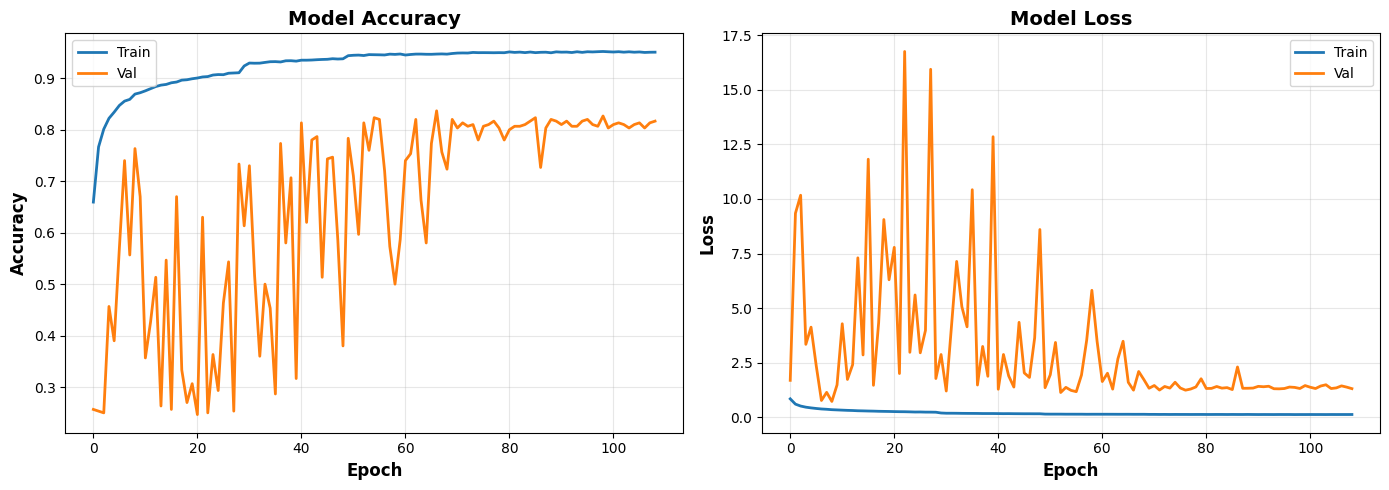


Best val accuracy: 83.67% at epoch 67


[14:05:00] WARNING  At this time, the v2.11+ optimizer `tf.keras.optimizers.Adam` runs slowly on    ]8;id=861;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/optimizers/optimizer.py\optimizer.py]8;;\:]8;id=40064;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/optimizers/optimizer.py#70\70]8;;\
                    M1/M2 Macs, please use the legacy Keras optimizer instead, located at                          
                    `tf.keras.optimizers.legacy.Adam`.                                                             


COMPREHENSIVE EVALUATION

Accuracy Summary:
  Training:   92.98%
  Validation: 83.67%
  Test:       43.33%

Overfitting Analysis:
  Train-Val gap:  9.31%
  Train-Test gap: 49.64%
  GOOD: Minimal overfitting (<10%)


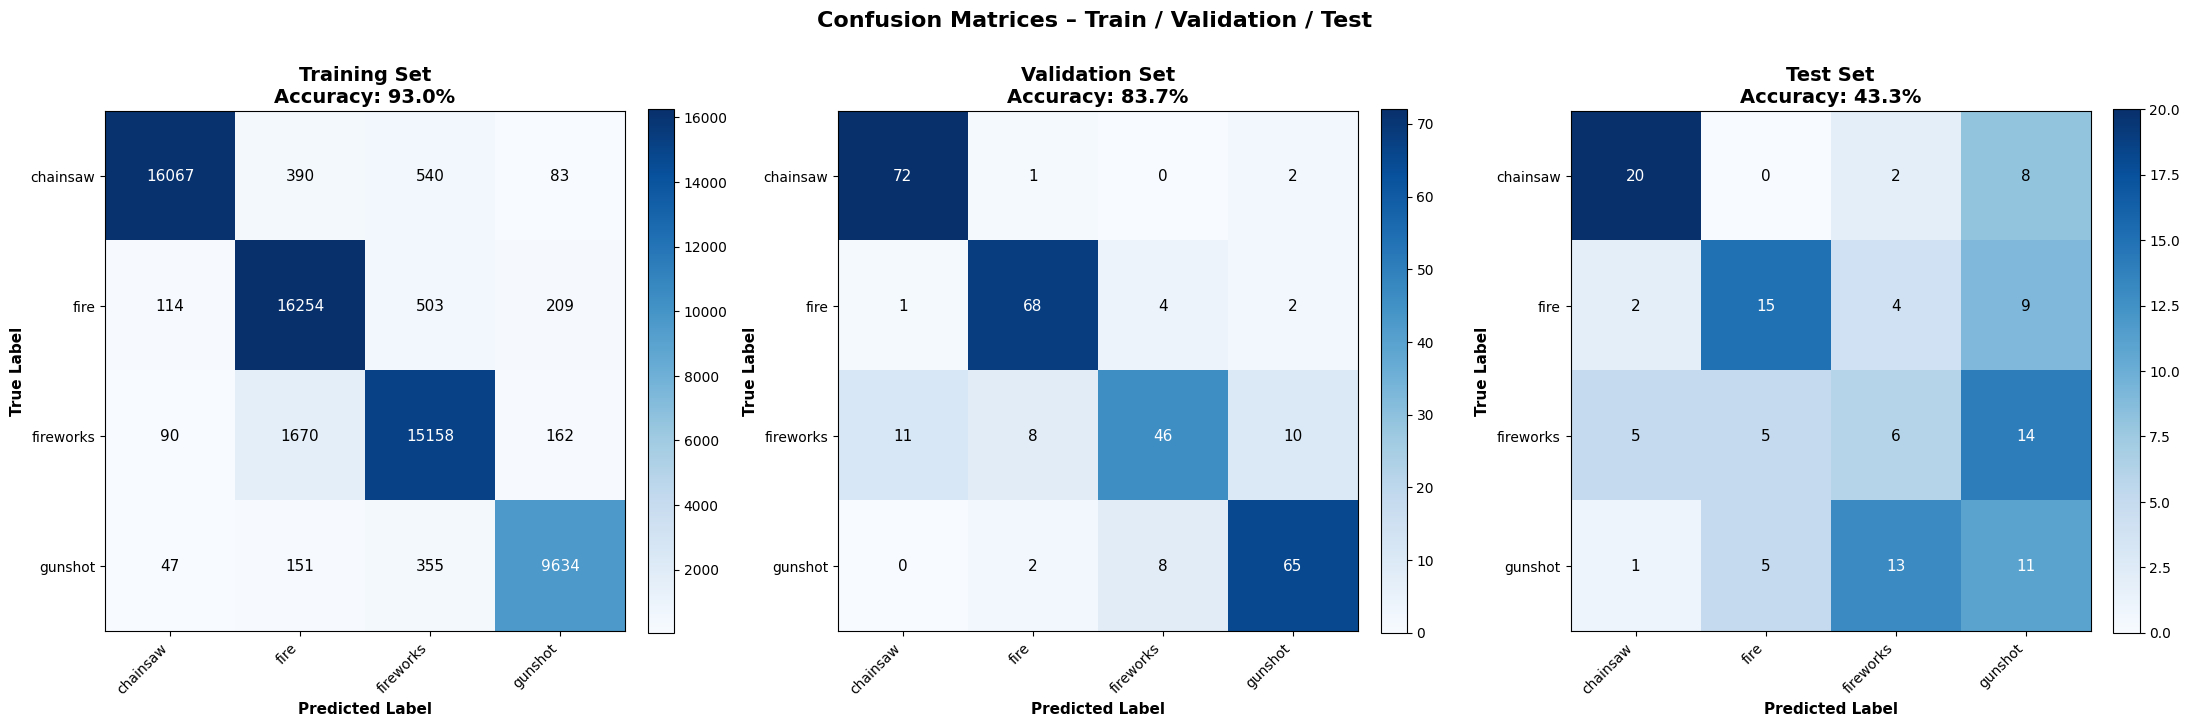


PER-CLASS METRICS (Test Set)

Class            Precision     Recall         F1    Support
-----------------------------------------------------------------
chainsaw             0.714      0.667      0.690         30
fire                 0.600      0.500      0.545         30
fireworks            0.240      0.200      0.218         30
gunshot              0.262      0.367      0.306         30
-----------------------------------------------------------------
Macro Avg            0.454      0.433      0.440        120

CONFIDENCE ANALYSIS

Training Set:
  Mean confidence:   0.948
  Median confidence: 1.000
  Min confidence:    0.279
  Max confidence:    1.000

Validation Set:
  Mean confidence:   0.968
  Median confidence: 1.000
  Min confidence:    0.538
  Max confidence:    1.000

Test Set:
  Mean confidence:   0.909
  Median confidence: 0.992
  Min confidence:    0.438
  Max confidence:    1.000

SAVING MODEL
Model saved: ./data/models/models_cnn/final_model.keras
INFO:tensorflow:Ass

[14:05:10] INFO     Assets written to:                                                          ]8;id=969411;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/tensorflow/python/saved_model/builder_impl.py\builder_impl.py]8;;\:]8;id=597090;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/tensorflow/python/saved_model/builder_impl.py#801\801]8;;\
                    /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmpxtoh1mmy/assets                            

[14:05:12] WARNING  At this time, the v2.11+ optimizer `tf.keras.optimizers.RestoredOptimizer` runs ]8;id=620148;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/optimizers/optimizer.py\optimizer.py]8;;\:]8;id=969294;file:///Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/optimizers/optimizer.py#70\70]8;;\
                    slowly on M1/M2 Macs, please use the legacy Keras optimizer instead, located at                
                    `tf.keras.optimizers.legacy.RestoredOptimizer`.                                                

TFLite: ./data/models/models_cnn/model.tflite (37.3 KB)

Test Accuracy: 43.33%


2026-03-13 14:05:12.592009: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-13 14:05:12.592026: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-13 14:05:12.592450: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmpxtoh1mmy
2026-03-13 14:05:12.594787: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-13 14:05:12.594795: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/j0/2l325n1s1_jbvh_1rzxjy6k40000gn/T/tmpxtoh1mmy
2026-03-13 14:05:12.599176: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-03-13 14:05:12.601867: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-03-13 14:05:12.700784: I tensorflow/cc/saved_model/loader.

In [13]:
dataset = Dataset()
dataset.remove_class("background")
dataset.remove_class("birds")
dataset.remove_class("handsaw")
dataset.remove_class("helicopter")

model, metrics, classnames = main_pipeline(dataset, config)